# 6주차_데이터 전처리와 파생변수 생성 Ⅰ


- 데이터 표준화와 정규화 스케일링 실습

---

### ✅ 한 문장 정리 (3종 비교)

> **"변수의 상대적 영향력 조정이 중요하면 → `표준화(StandardScaler)`,**
> 
> 
> **변수 간의 거리나 절대 크기 비교가 중요하면 → `정규화(MinMaxScaler)`,**
> 
> **이상치가 많아 왜곡 없이 스케일링하려면 → `로버스트 스케일링(RobustScaler)`"**
> 

---




## 🔍 요약 비교 표

| 스케일링 방법 | 언제 사용하나 | 중심 기준 | 이상치 민감도 | 사용 예시 |
| --- | --- | --- | --- | --- |
| **표준화**(StandardScaler) | 변수 간 **영향력 조정** 필요할 때 | 평균(μ), 표준편차(σ) | ❗ 민감함 | 선형 회귀, 로지스틱 회귀, SVM |
| **정규화**(MinMaxScaler) | **거리 계산** 중요할 때 | 최소, 최대값 | ❗ 매우 민감함 | KNN, K-Means, 딥러닝 입력 |
| **로버스트 스케일링**(RobustScaler) | **이상치가 많을 때** | 중앙값, IQR | ✅ 매우 강함 | 실측 데이터, 금융 시계열 등 |

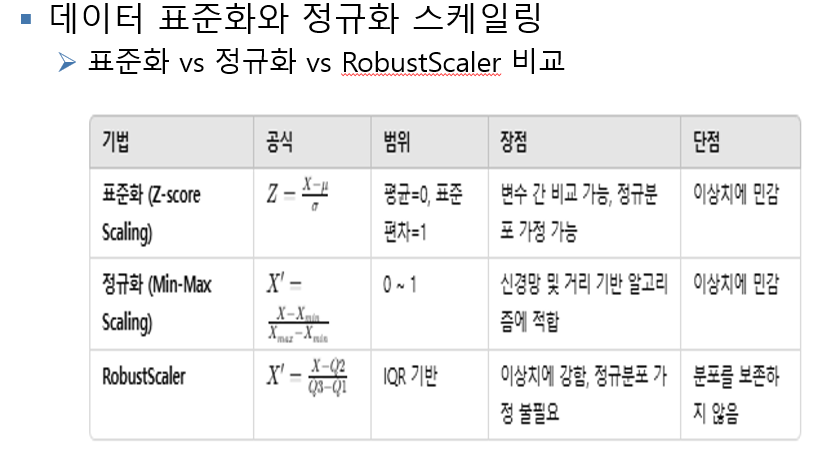

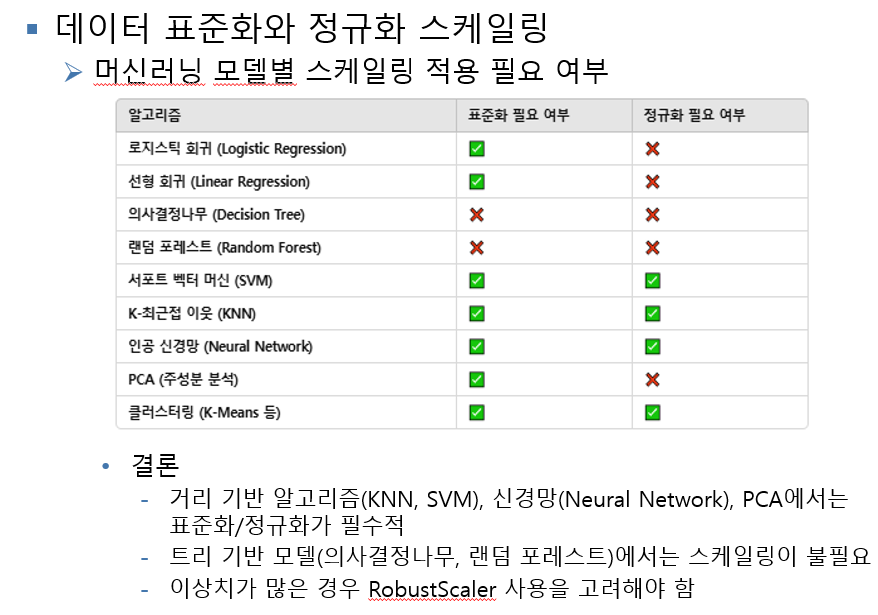

In [34]:
# 데이터 분석 및 머신러닝 모델에서 변수들의 단위 차이와 편차를 보정하기 위한 스케일링 기법 설명

# 주요 스케일링 방식: 표준화(Standardization), 정규화(Normalization), 이상치 강건화(RobustScaler)

# 표준화(Standardization, Z-score Scaling) 설명

# 평균이 0이고 표준편차가 1이 되도록 값의 분포를 변환
# 이상치에 민감하며, 거리 기반 알고리즘(KNN, SVM)이나 PCA 등에 자주 사용됨
# 공식: (X - 평균) / 표준편차

# 정규화(Normalization, Min-Max Scaling) 설명

# 최소값을 0, 최대값을 1로 변환하여 모든 데이터를 0~1 사이로 조정
# 이상치에 매우 민감하므로 데이터 분포에 따라 신중하게 사용 필요
# 이미지 데이터(픽셀 값 0~255)나 신경망(Neural Network)에서 자주 사용됨
# 공식: (X - 최소값) / (최대값 - 최소값)

# 이상치에 강한 스케일링: RobustScaler 설명

# 중앙값(Median)과 사분위수(IQR)를 기준으로 스케일링하여 이상치 영향을 최소화
# 공식: (X - Q2) / (Q3 - Q1), Q2는 중앙값, Q3-Q1은 IQR
# 이상치가 많은 데이터에서 강력한 성능을 발휘함
# 사용 예시: 트리 기반 모델, 회귀모델 등

# 표준화, 정규화, RobustScaler 비교

# 표준화: 이상치 민감, 평균 기준, 거리 기반 모델 적합
# 정규화: 이상치 민감, 0~1 범위로 압축, 신경망 모델 적합
# RobustScaler: 이상치 강건, 사분위수 기준, 이상치 많은 경우 효과적

# 머신러닝 알고리즘별 스케일링 필요 여부 요약

# 스케일링 필수: 거리 기반 알고리즘(KNN, SVM), 신경망(Neural Network), PCA
# 스케일링 불필요: 트리 기반 모델(Decision Tree, Random Forest 등)



In [35]:
# 필요한 패키지 설치
from sklearn.preprocessing import StandardScaler
# 평균이 0, 표준편차가 1이 되도록 데이터를 표준화(정규화)하는 스케일러를 임포트함
# 평균 중심 정규화로, 정규분포 가정이 있는 모델(예: 선형회귀, 로지스틱 회귀 등)에 적합함

from sklearn.preprocessing import MinMaxScaler
# 데이터를 최소값 0, 최대값 1 사이로 스케일링하는 스케일러를 임포트함
# 값의 범위가 고정되어야 하는 신경망 계열 모델 등에 주로 사용됨

from sklearn.preprocessing import RobustScaler
# 중위수(median)와 IQR(사분위 범위)을 기준으로 스케일링하는 스케일러를 임포트함
# 이상치에 강건한 스케일링 방식으로, 이상치가 많은 데이터에 적합함

import matplotlib.pyplot as plt
# 시각화 도구 matplotlib의 pyplot 모듈을 임포트함
# 데이터의 분포나 변환 결과를 시각적으로 확인할 때 사용됨

import pandas as pd
# 데이터프레임 기반의 데이터 처리 및 분석을 위한 pandas 라이브러리를 임포트함

import seaborn as sns
# 고급 통계 시각화를 위한 seaborn 라이브러리를 임포트함

plt.rcParams['figure.dpi'] = 300
# 그래프의 출력 해상도를 300 DPI로 설정함
# 고화질 출력이 필요할 때 사용되며, 논문용 이미지나 발표자료용 시각화에 유용함


In [36]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering
df = pd.read_csv("../../main/datasets/wine-clustering.csv")

# 데이터 샘플 확인
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [37]:
# 기존 데이터 컬럼 별 평균, 분산 확인

# 각 컬럼의 평균값
print(df.mean())
print('\n')
# 각 컬럼의 분산값
print(df.var())

Alcohol                  13.000618
Malic_Acid                2.336348
Ash                       2.366517
Ash_Alcanity             19.494944
Magnesium                99.741573
Total_Phenols             2.295112
Flavanoids                2.029270
Nonflavanoid_Phenols      0.361854
Proanthocyanins           1.590899
Color_Intensity           5.058090
Hue                       0.957449
OD280                     2.611685
Proline                 746.893258
dtype: float64


Alcohol                     0.659062
Malic_Acid                  1.248015
Ash                         0.075265
Ash_Alcanity               11.152686
Magnesium                 203.989335
Total_Phenols               0.391690
Flavanoids                  0.997719
Nonflavanoid_Phenols        0.015489
Proanthocyanins             0.327595
Color_Intensity             5.374449
Hue                         0.052245
OD280                       0.504086
Proline                 99166.717355
dtype: float64


In [38]:
# 전체 컬럼 표준화

# 데이터 표준화 적용
StandardScaler = StandardScaler()
# sklearn의 StandardScaler 객체를 생성함
# 각 변수에 대해 평균을 0, 표준편차를 1로 변환하는 표준화(정규화)를 수행함
# 변수 간 스케일 차이가 있는 경우 거리 기반 알고리즘(KNN, SVM 등)에 영향을 줄 수 있으므로 스케일 통일이 필요함

df_stand = StandardScaler.fit_transform(df)
# fit_transform() 메서드를 통해 df 전체에 대해 표준화를 적용함
# 반환값은 numpy 배열 형태이며, 각 열에 대해 z-score 방식으로 변환된 결과임

# 컬럼명 결합
df_stand = pd.DataFrame(data=df_stand, columns=df.columns)
# numpy 배열로 변환된 표준화 결과에 원래의 컬럼명을 붙여 pandas DataFrame으로 다시 구성함
# 이후 분석 및 시각화를 pandas 형식으로 계속 이어가기 위한 처리임

df_stand.head()
# 표준화된 결과의 상위 5개 행을 출력함
# 각 컬럼이 평균 0, 표준편차 1을 중심으로 스케일링되었는지 확인하는 절차임

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [39]:
# 데이터 표준화 스케일링 후 컬럼 별 평균, 분산 확인

# 각 컬럼의 평균값
print(df_stand.mean())
print('\n')
# 각 컬럼의 분산값
print(df_stand.var())

Alcohol                -8.382808e-16
Malic_Acid             -1.197544e-16
Ash                    -8.370333e-16
Ash_Alcanity           -3.991813e-17
Magnesium              -3.991813e-17
Total_Phenols           0.000000e+00
Flavanoids             -3.991813e-16
Nonflavanoid_Phenols    3.592632e-16
Proanthocyanins        -1.197544e-16
Color_Intensity         2.494883e-17
Hue                     1.995907e-16
OD280                   3.193450e-16
Proline                -1.596725e-16
dtype: float64


Alcohol                 1.00565
Malic_Acid              1.00565
Ash                     1.00565
Ash_Alcanity            1.00565
Magnesium               1.00565
Total_Phenols           1.00565
Flavanoids              1.00565
Nonflavanoid_Phenols    1.00565
Proanthocyanins         1.00565
Color_Intensity         1.00565
Hue                     1.00565
OD280                   1.00565
Proline                 1.00565
dtype: float64


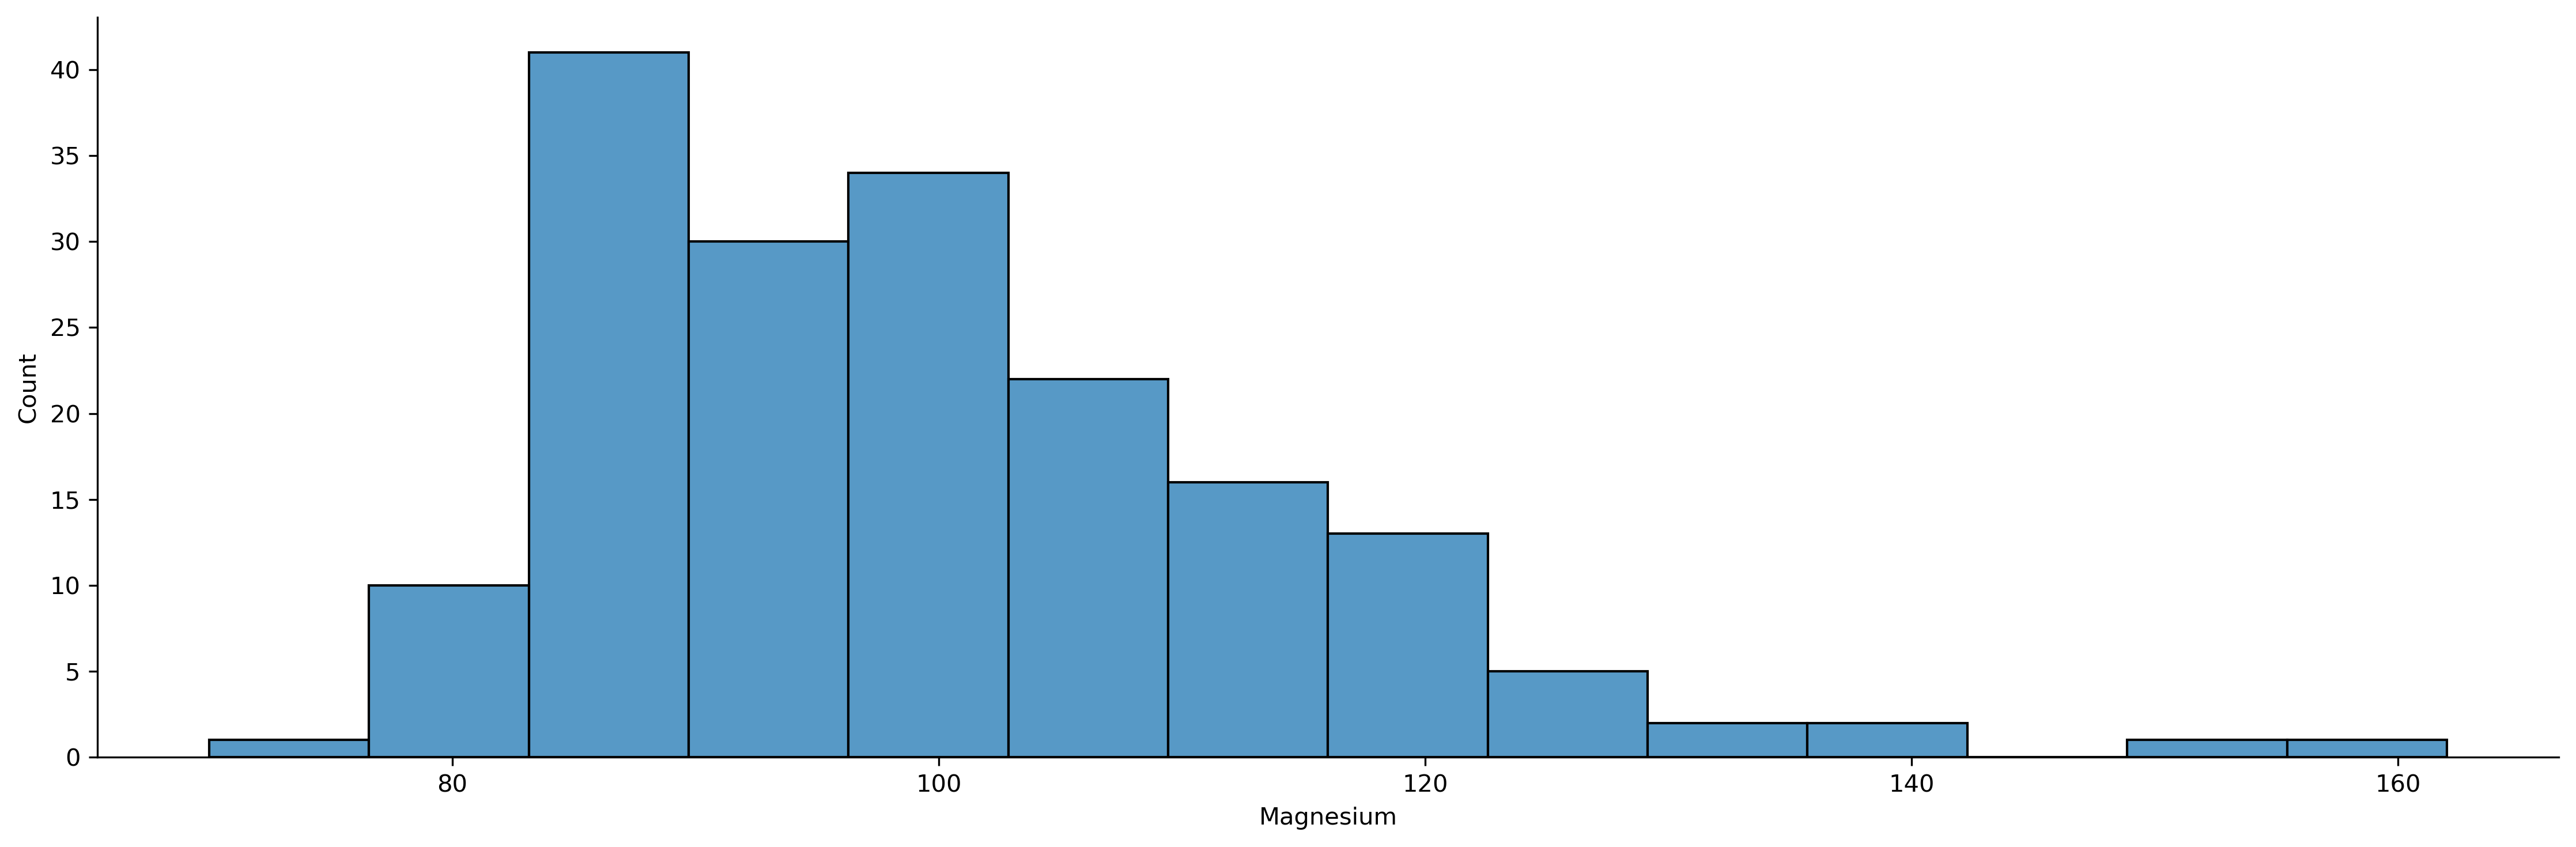

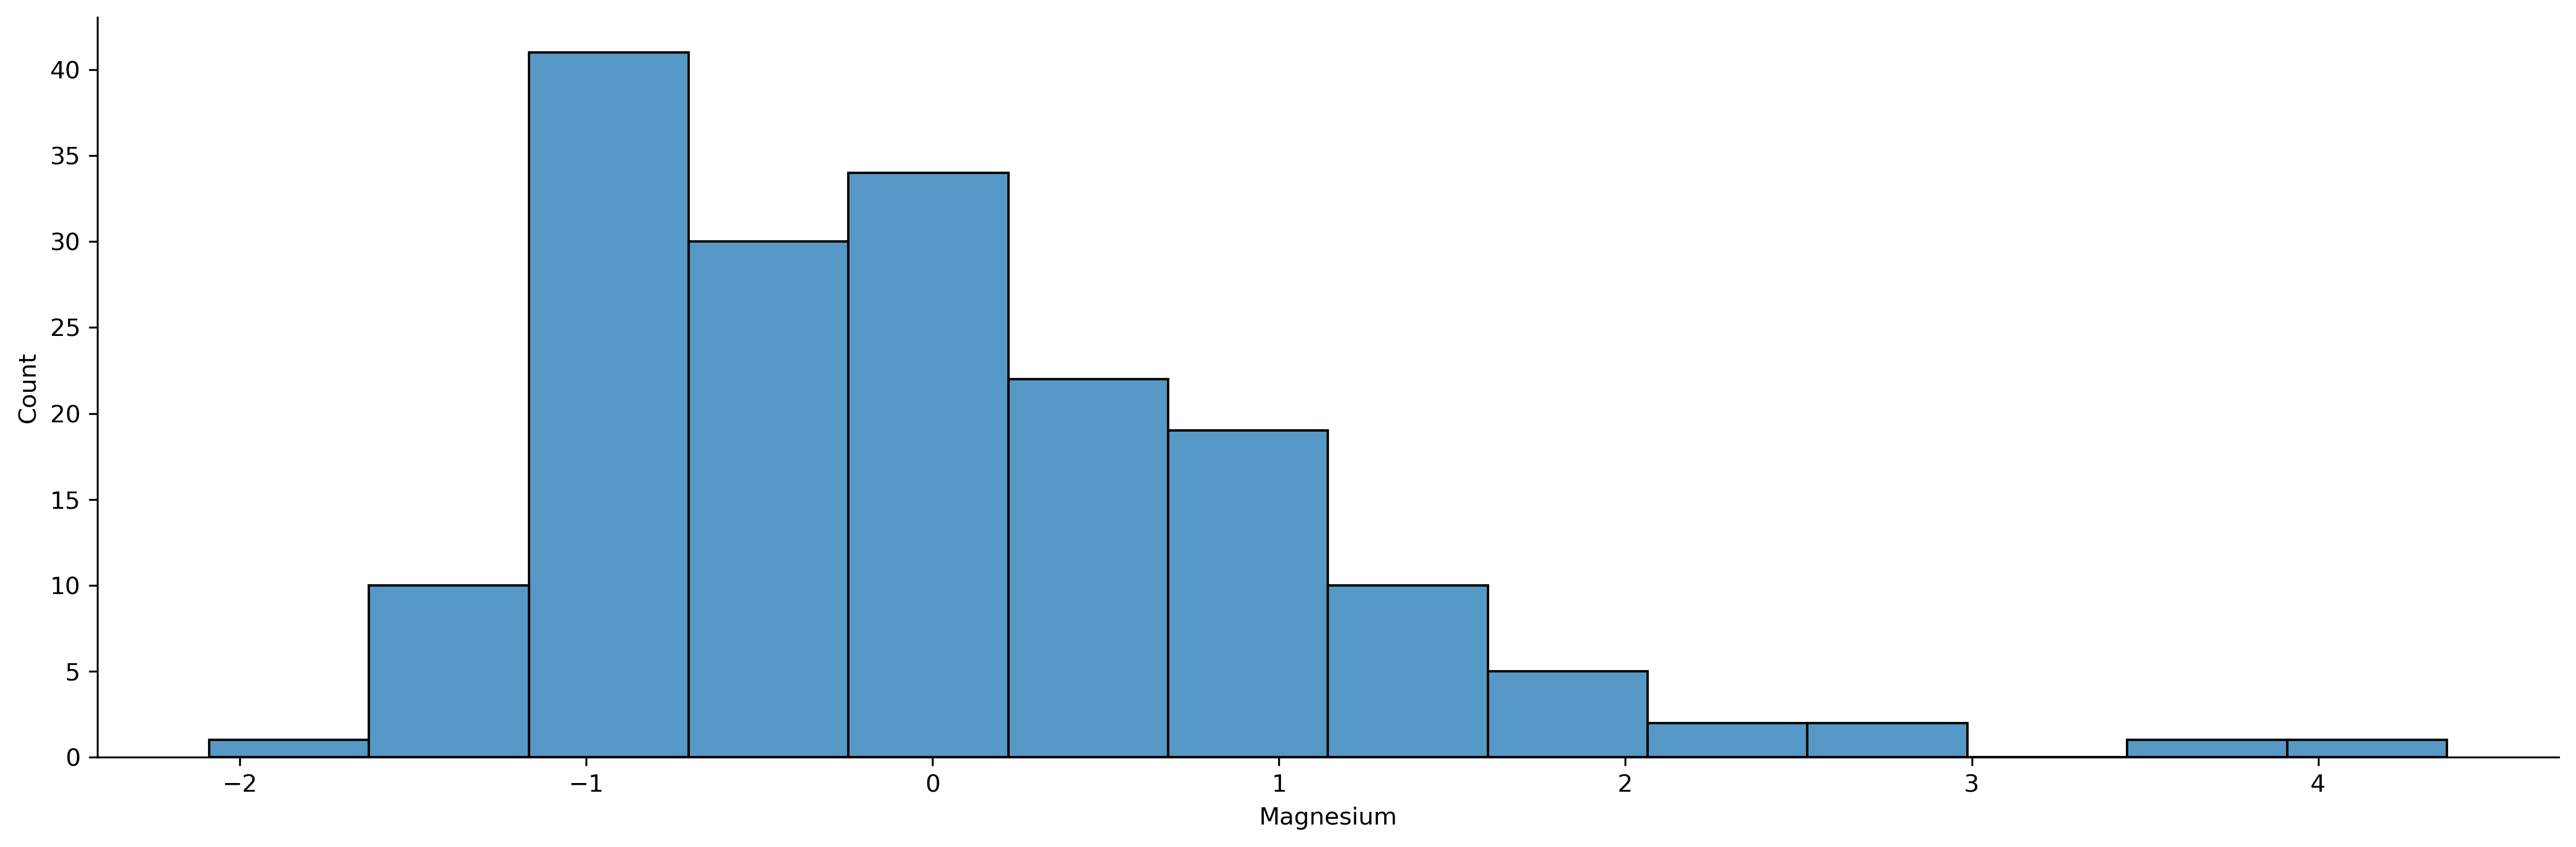

In [40]:
# Magnesium 컬럼 표준화 스케일링 전과 후 분포 비교

%matplotlib inline
sns.displot(df['Magnesium'],height = 5, aspect = 3)
sns.displot(df_stand['Magnesium'],height = 5, aspect = 3)

plt.show()

In [41]:
# 전체 컬럼 정규화

# 데이터 정규화 적용
MinMaxScaler = MinMaxScaler()
# sklearn의 MinMaxScaler 객체를 생성함
# 각 변수 값을 0과 1 사이의 범위로 정규화함
# 최소값은 0, 최대값은 1이 되도록 선형 변환을 수행함

df_minmax = MinMaxScaler.fit_transform(df)
# fit_transform()을 통해 전체 데이터프레임(df)에 정규화를 적용함
# 반환값은 numpy 배열이며, 각 열의 값이 0~1 범위 내로 조정됨

# 컬럼명 결합
df_minmax = pd.DataFrame(data=df_minmax, columns=df.columns)
# 정규화된 numpy 배열에 원래 컬럼명을 붙여서 pandas DataFrame 형식으로 복구함
# 이후 분석 또는 시각화 시 컬럼 단위로 접근할 수 있도록 처리함

df_minmax.head()
# 정규화가 적용된 데이터프레임(df_minmax)의 상위 5개 행을 출력함
# 각 컬럼의 값이 0과 1 사이로 스케일링되었는지 확인하기 위한 검증 단계임


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963


In [42]:
# 정규화 적용 컬럼 최솟값, 최댓값 확인

print(df_minmax.min()) #최솟값 
print('\n')
print(df_minmax.max()) #최댓값 

Alcohol                 0.0
Malic_Acid              0.0
Ash                     0.0
Ash_Alcanity            0.0
Magnesium               0.0
Total_Phenols           0.0
Flavanoids              0.0
Nonflavanoid_Phenols    0.0
Proanthocyanins         0.0
Color_Intensity         0.0
Hue                     0.0
OD280                   0.0
Proline                 0.0
dtype: float64


Alcohol                 1.0
Malic_Acid              1.0
Ash                     1.0
Ash_Alcanity            1.0
Magnesium               1.0
Total_Phenols           1.0
Flavanoids              1.0
Nonflavanoid_Phenols    1.0
Proanthocyanins         1.0
Color_Intensity         1.0
Hue                     1.0
OD280                   1.0
Proline                 1.0
dtype: float64


In [43]:
# 데이터 정규화 스케일링 후 컬럼 별 평균, 분산 확인

# 각 컬럼의 평균값
print(df_minmax.mean())
print('\n')
# 각 컬럼의 분산값
print(df_minmax.var())

Alcohol                 0.518584
Malic_Acid              0.315484
Ash                     0.538244
Ash_Alcanity            0.458502
Magnesium               0.323278
Total_Phenols           0.453487
Flavanoids              0.356386
Nonflavanoid_Phenols    0.437460
Proanthocyanins         0.372523
Color_Intensity         0.322363
Hue                     0.388170
OD280                   0.491460
Proline                 0.334446
dtype: float64


Alcohol                 0.045641
Malic_Acid              0.048744
Ash                     0.021523
Ash_Alcanity            0.029633
Magnesium               0.024101
Total_Phenols           0.046574
Flavanoids              0.044407
Nonflavanoid_Phenols    0.055139
Proanthocyanins         0.032600
Color_Intensity         0.039127
Hue                     0.034533
OD280                   0.067636
Proline                 0.050451
dtype: float64


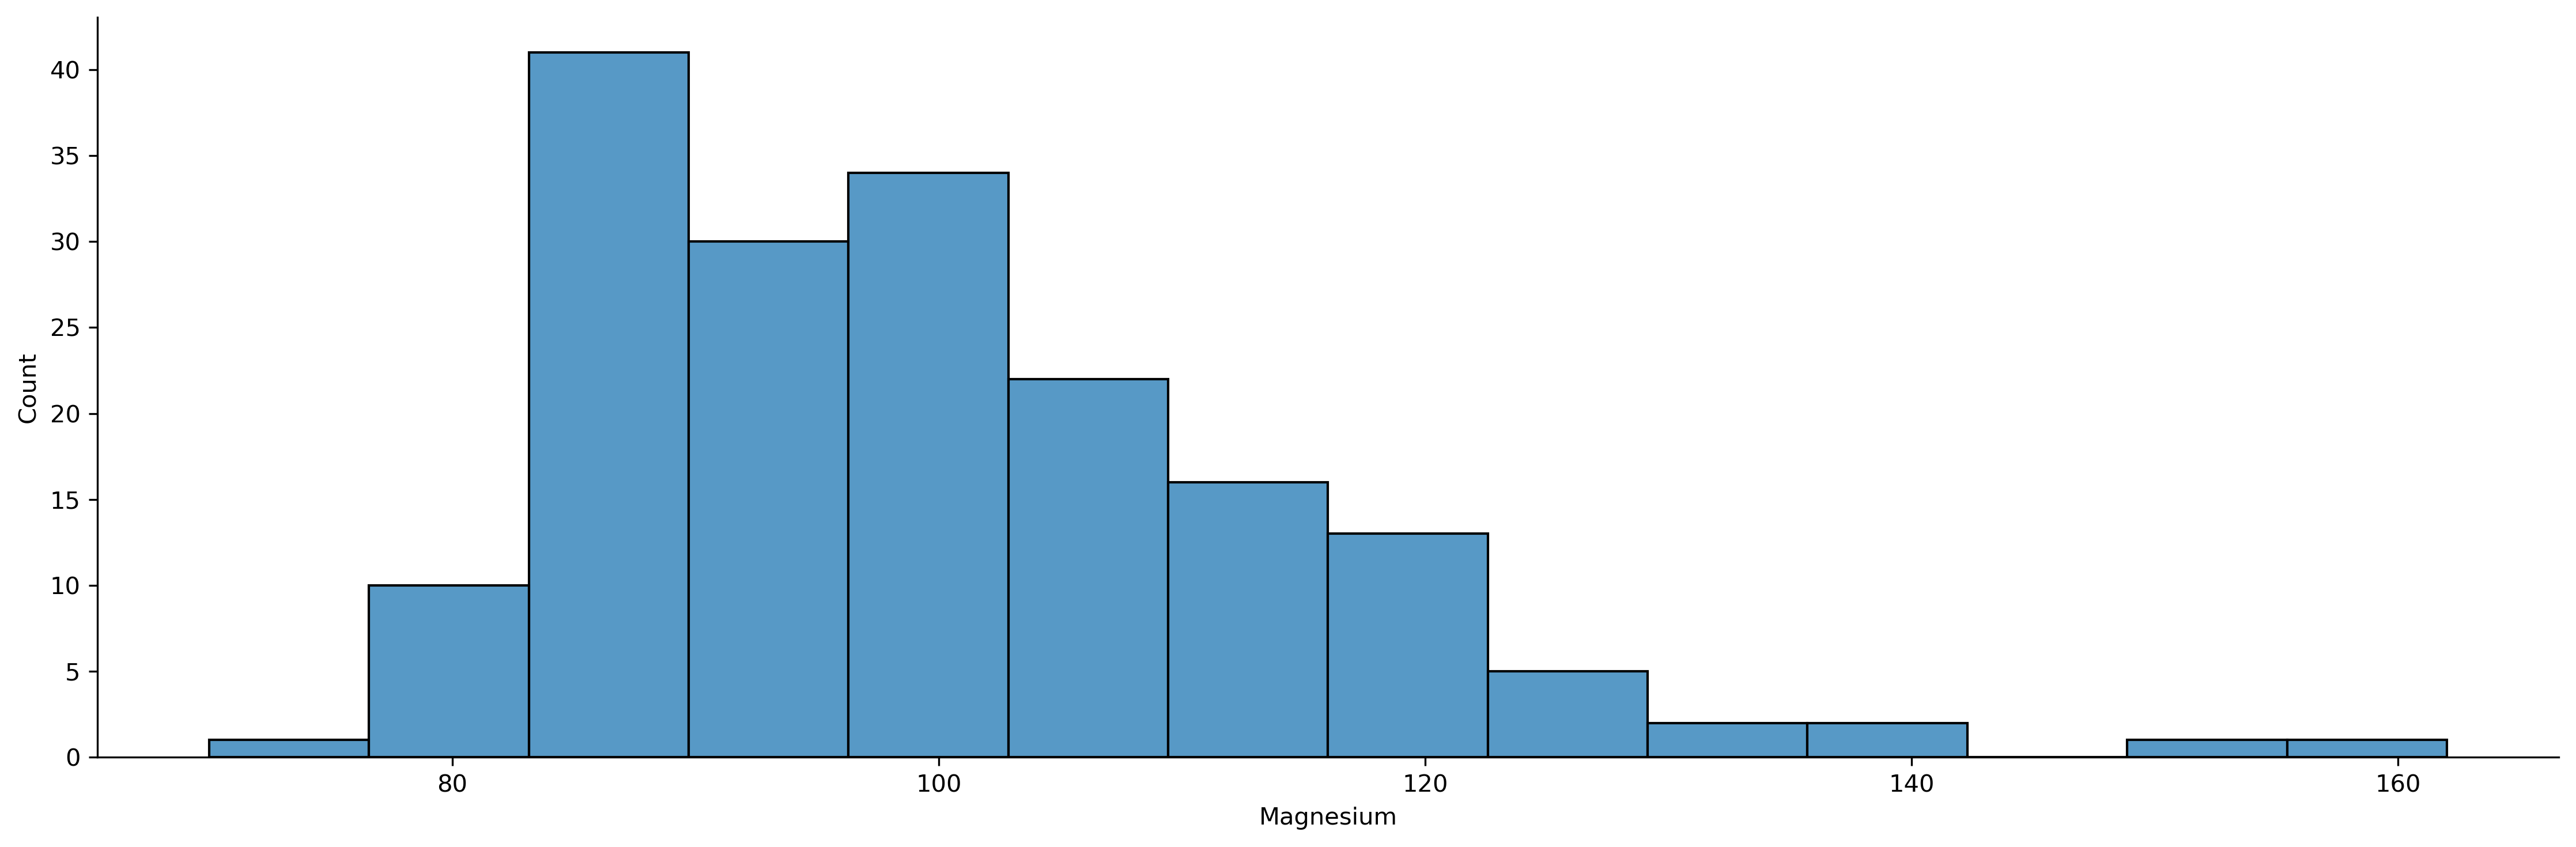

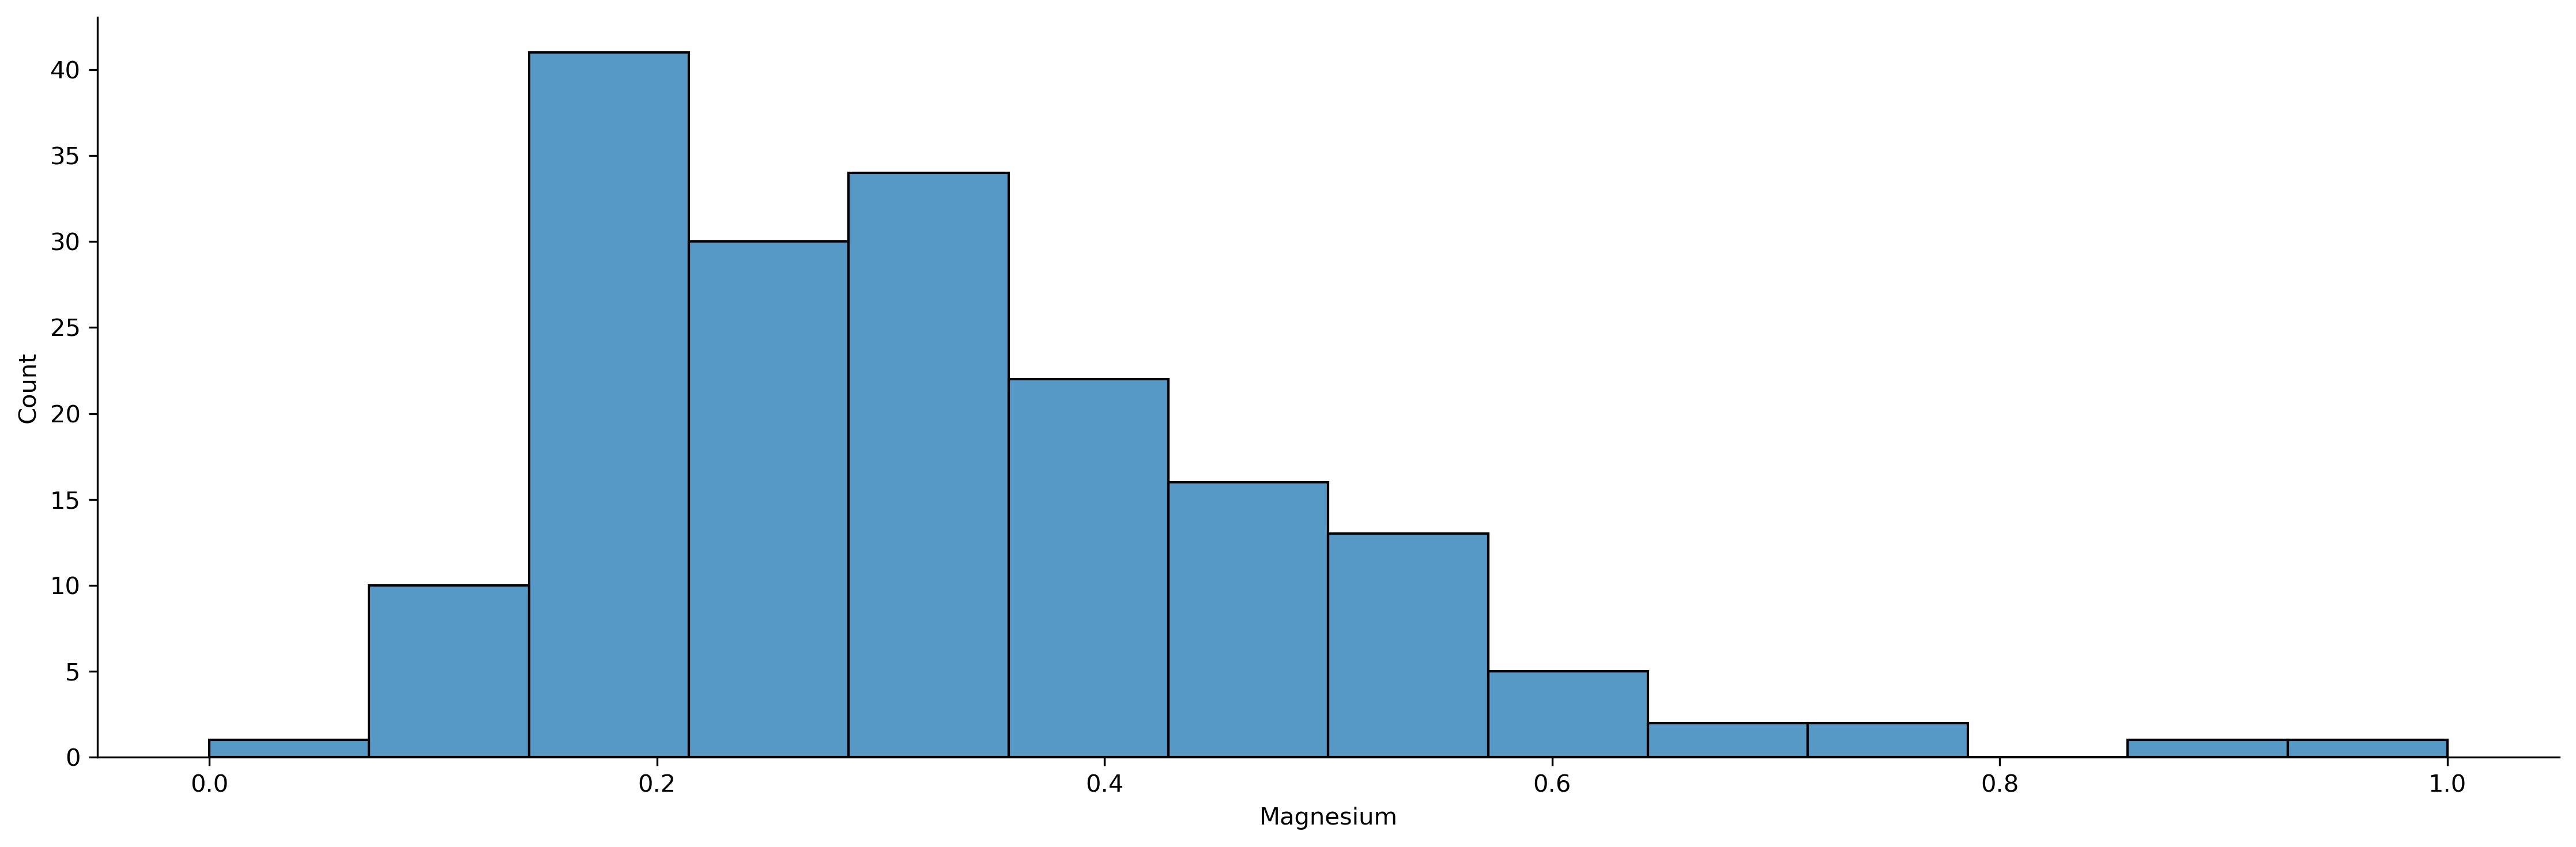

In [44]:
# Magnesium 컬럼 정규화 스케일링 전과 후 분포 비교

%matplotlib inline
sns.displot(df['Magnesium'],height = 5, aspect = 3)
sns.displot(df_minmax['Magnesium'],height = 5, aspect = 3)

plt.show()

In [45]:
# 전체 컬럼 RobustScaler

# 데이터 RobustScaler 적용
RobustScaler = RobustScaler()
# sklearn의 RobustScaler 객체를 생성함
# 중앙값(median)과 IQR(Interquartile Range, 사분위 범위)을 기준으로 스케일링함
# RobustScaler는 "가운데 값(중앙값)을 중심으로 하고, 중간 50% 폭(IQR)을 기준으로 비율을 조정하는 스케일링"
# 이상치의 영향을 최소화할 수 있어 이상치가 많은 데이터셋에 적합한 스케일링 방식임

df_robust = RobustScaler.fit_transform(df)
# fit_transform()을 통해 전체 데이터프레임(df)에 RobustScaler를 적용함
# 중앙값 기준으로 재조정된 값을 가진 numpy 배열이 반환됨

# 컬럼명 결합
df_robust = pd.DataFrame(data=df_robust, columns=df.columns)
# 스케일링 결과를 pandas DataFrame으로 복구하며, 원래의 컬럼명을 유지함
# 이후 분석 및 시각화 시 컬럼 접근이 용이하도록 처리함

df_robust.head()
# RobustScaler가 적용된 데이터프레임(df_robust)의 상위 5개 행을 출력함
# 각 컬럼의 스케일이 중앙값 기준으로 얼마나 재조정되었는지 확인하는 단계임


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


In [46]:
# 데이터 RobustScaler 적용 후 컬럼 별 평균, 분산 확인

# 각 컬럼의 평균값
print(df_robust.mean())
print('\n')
# 각 컬럼의 분산값
print(df_robust.var())

Alcohol                -0.037553
Malic_Acid              0.318479
Ash                     0.018754
Ash_Alcanity           -0.001176
Magnesium               0.091662
Total_Phenols          -0.056631
Flavanoids             -0.063312
Nonflavanoid_Phenols    0.130471
Proanthocyanins         0.051284
Color_Intensity         0.123520
Hue                    -0.022372
OD280                  -0.136564
Proline                 0.151482
dtype: float64


Alcohol                 0.381132
Malic_Acid              0.569766
Ash                     0.623277
Ash_Alcanity            0.603174
Magnesium               0.565067
Total_Phenols           0.350252
Flavanoids              0.357746
Nonflavanoid_Phenols    0.552056
Proanthocyanins         0.668561
Color_Intensity         0.605204
Hue                     0.458666
OD280                   0.331842
Proline                 0.422453
dtype: float64


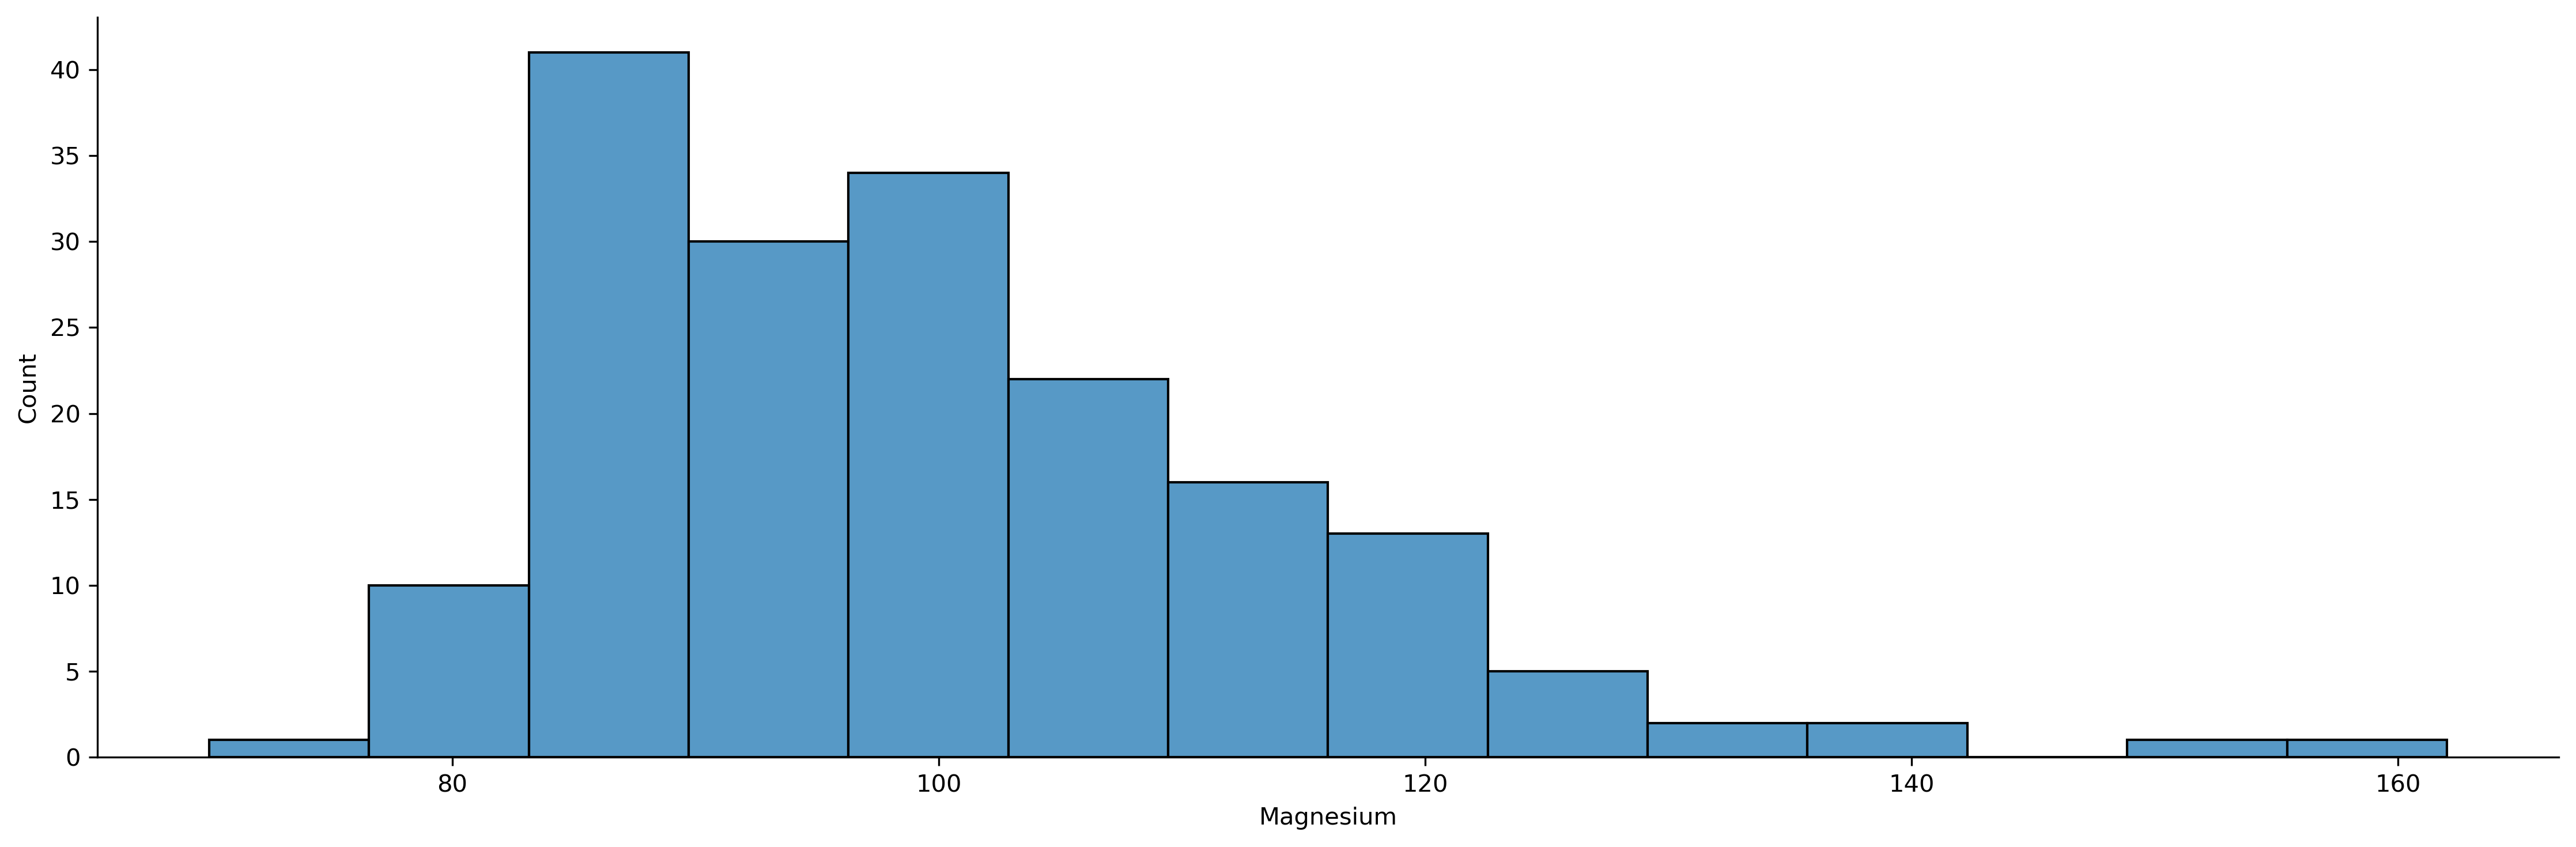

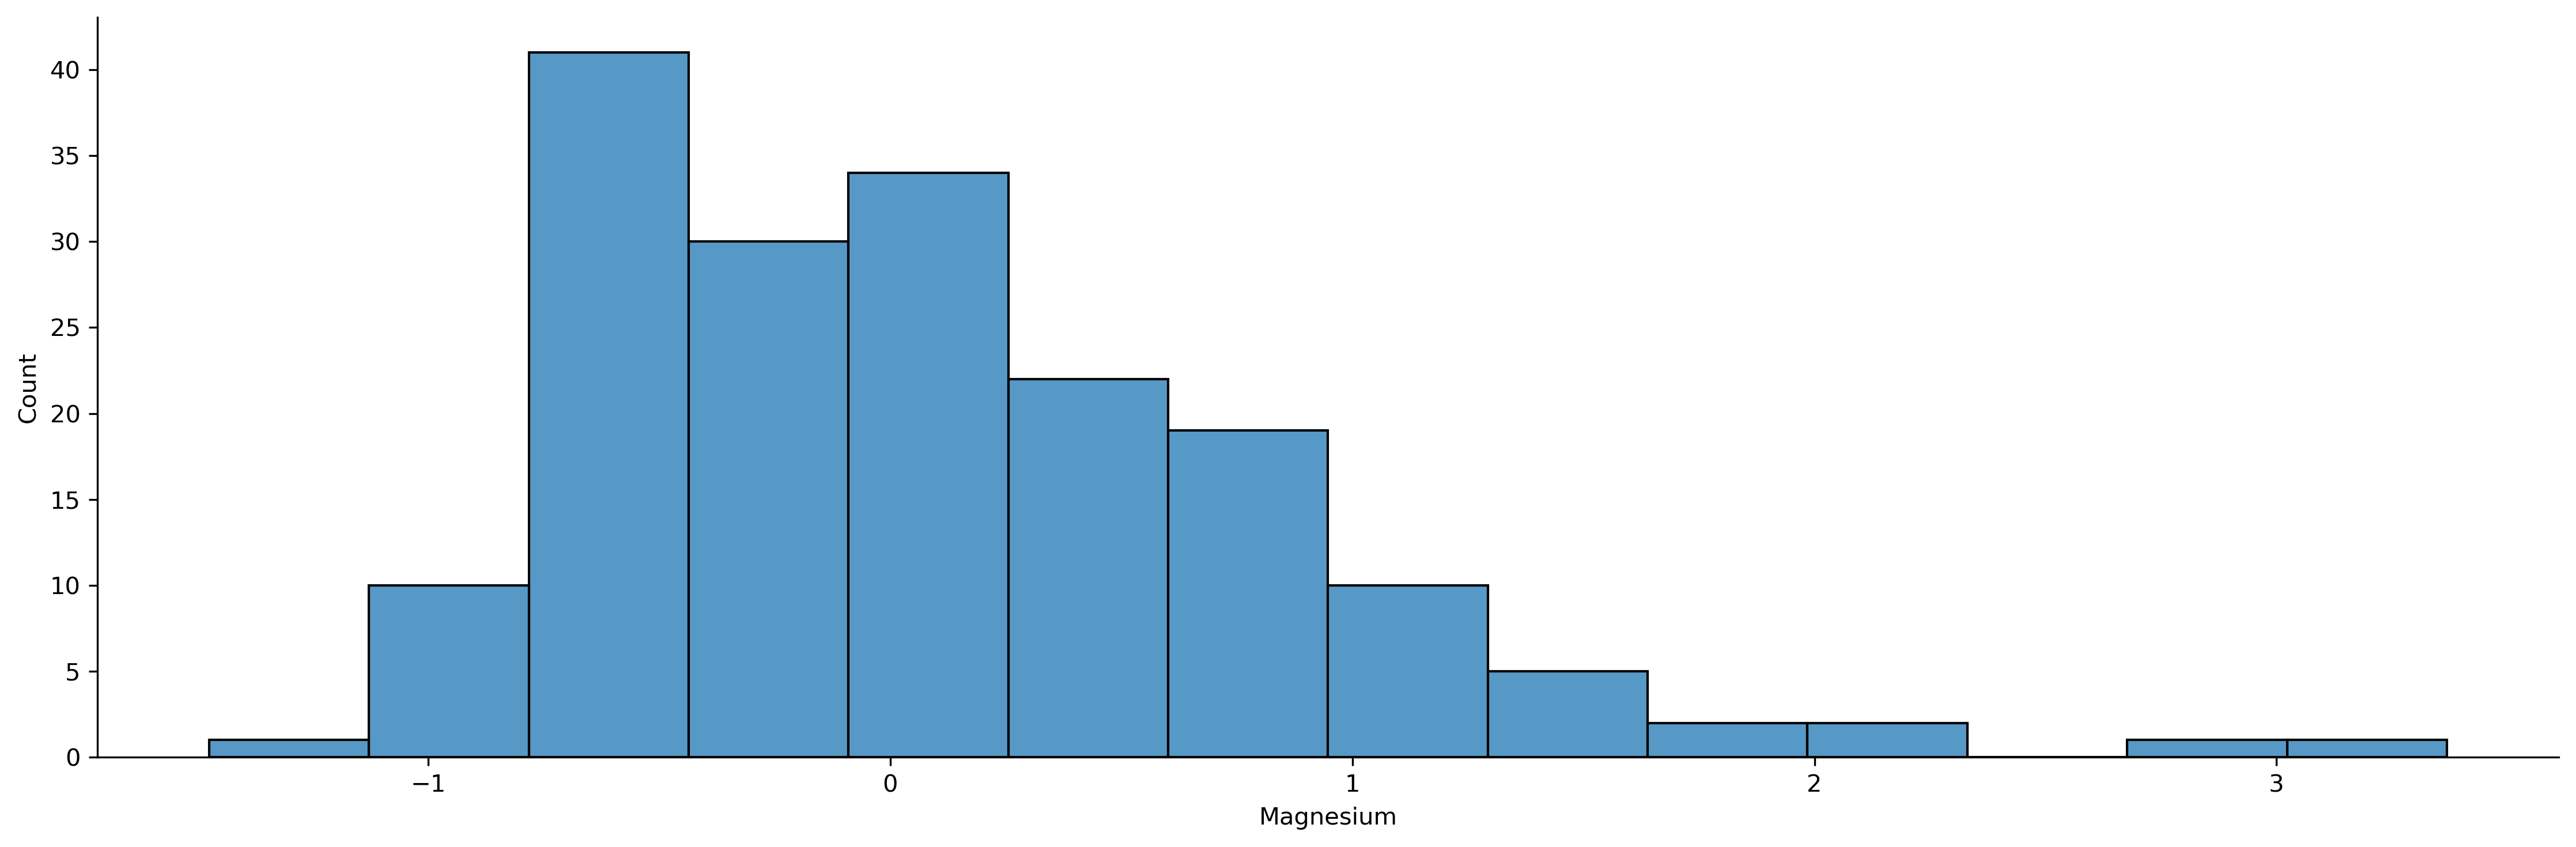

In [47]:
# Magnesium 컬럼 RobustScaler 적용 전과 후 분포 비교

%matplotlib inline
sns.displot(df['Magnesium'],height = 5, aspect = 3)
sns.displot(df_robust['Magnesium'],height = 5, aspect = 3)

plt.show()